In [13]:
!pip install catboost

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap
import joblib

In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
df = pd.read_csv(
    "/content/drive/MyDrive/CAC_IITG/Airline/airline_segmented.csv"
)

df.shape

(389065, 46)

In [17]:
df['Cancelled'].value_counts()

,count
Cancelled,
0,340952
1,48113


In [18]:
df['Cancelled'].value_counts(
    normalize=True
)*100

,proportion
Cancelled,
0,87.633686
1,12.366314


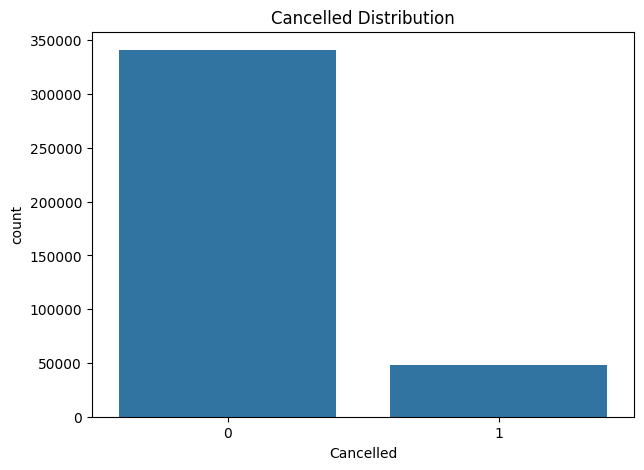

In [19]:
# Plot Target Variable

plt.figure(figsize=(7,5))

sns.countplot(
    x='Cancelled',
    data=df
)

plt.title(
    'Cancelled Distribution'
)

plt.show()

In [20]:
y = df['Cancelled']

In [21]:
drop_cols = [

    'Cancelled',
    'Loyalty Number'

]

In [22]:
errors='ignore'
X = df.drop(
    columns=drop_cols,
    errors='ignore'
)

In [23]:
X.dtypes

,0
Year,int64
Month,int64
Total Flights,float64
Distance,float64
Points Accumulated,float64
Points Redeemed,int64
Dollar Cost Points Redeemed,int64
Country,object
Province,object
City,object


In [24]:
num_cols = X.select_dtypes(
    include=[
        'int64',
        'float64'
    ]
).columns

**Separate Features**

In [25]:
num_cols = X.select_dtypes(
    include=[
        'int64',
        'float64'
    ]
).columns

In [26]:
cat_cols = X.select_dtypes(
    include=[
        'object',
        'category'
    ]
).columns

**Train-Test Split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y

)

**Preprocessing Pipeline**

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [29]:
num_pipe = Pipeline([

    (
        'imputer',
        SimpleImputer(
            strategy='median'
        )
    ),

    (
        'scaler',
        StandardScaler()
    )

])

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
cat_pipe = Pipeline([

    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent'
        )
    ),

    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )

])

In [32]:
preprocessor = ColumnTransformer([

    (
        'num',
        num_pipe,
        num_cols
    ),

    (
        'cat',
        cat_pipe,
        cat_cols
    )

])

In [33]:
X_train_prepared = preprocessor.fit_transform(
    X_train
)

X_test_prepared = preprocessor.transform(
    X_test
)

In [34]:
y_train.value_counts(
    normalize=True
)

,proportion
Cancelled,
0,0.876338
1,0.123662


In [35]:
# Apply SMOTE
# Minority Class < 30%

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train_prepared,
    y_train

)

In [36]:
y_train_smote.value_counts()

,count
Cancelled,
0,272762
1,272762


**Baseline Models**

In [37]:
models = {

    'Logistic Regression':
    LogisticRegression(
        max_iter=1000
    ),

    'Decision Tree':
    DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest':
    RandomForestClassifier(
        random_state=42
    ),

    'XGBoost':
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    'LightGBM':
    LGBMClassifier(
        random_state=42
    ),

    'CatBoost':
    CatBoostClassifier(
        verbose=0,
        random_state=42
    )

}

**Train Models**

In [38]:
results = []

for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    pred = model.predict(
        X_test_prepared
    )

    prob = model.predict_proba(
        X_test_prepared
    )[:,1]

    acc = accuracy_score(
        y_test,
        pred
    )

    prec = precision_score(
        y_test,
        pred
    )

    rec = recall_score(
        y_test,
        pred
    )

    f1 = f1_score(
        y_test,
        pred
    )

    auc = roc_auc_score(
        y_test,
        prob
    )

    results.append([

        name,
        acc,
        prec,
        rec,
        f1,
        auc

    ])

[LightGBM] [Info] Number of positive: 272762, number of negative: 272762
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.272564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13081
[LightGBM] [Info] Number of data points in the train set: 545524, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**Model Comparison**

In [39]:
model_results = pd.DataFrame(

    results,

    columns=[

        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'

    ]

)

model_results.sort_values(
    'ROC_AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
5,CatBoost,0.958066,0.919636,0.724202,0.810302,0.979594
2,Random Forest,0.970416,0.940017,0.812636,0.871698,0.979361
3,XGBoost,0.901854,0.636589,0.480931,0.547919,0.908281
4,LightGBM,0.879120,0.549793,0.124493,0.203016,0.859695
0,Logistic Regression,0.634226,0.231217,0.842045,0.362810,0.755566
1,Decision Tree,0.849627,0.408940,0.484880,0.443684,0.693084


**Train Final Model**

In [40]:
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

**Predictions**

In [41]:
y_pred = final_model.predict(
    X_test_prepared
)

y_prob = final_model.predict_proba(
    X_test_prepared
)[:,1]

**Metrics Table**

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[

        accuracy_score(
            y_test,
            y_pred
        ),

        precision_score(
            y_test,
            y_pred
        ),

        recall_score(
            y_test,
            y_pred
        ),

        f1_score(
            y_test,
            y_pred
        ),

        roc_auc_score(
            y_test,
            y_prob
        )

    ]

})

metrics

,Metric,Value
0,Accuracy,0.971290
1,Precision,0.944531
2,Recall,0.815754
3,F1 Score,0.875432
4,ROC AUC,0.980870


**Classification Report**

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     68190
           1       0.94      0.82      0.88      9623

    accuracy                           0.97     77813
   macro avg       0.96      0.90      0.93     77813
weighted avg       0.97      0.97      0.97     77813



**Confusion Matrix**

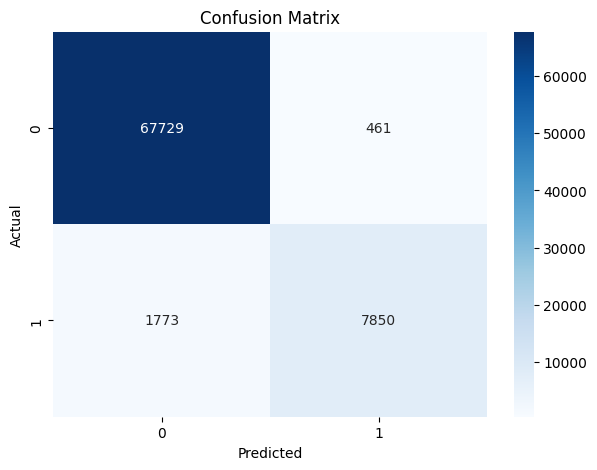

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

**ROC Curve**

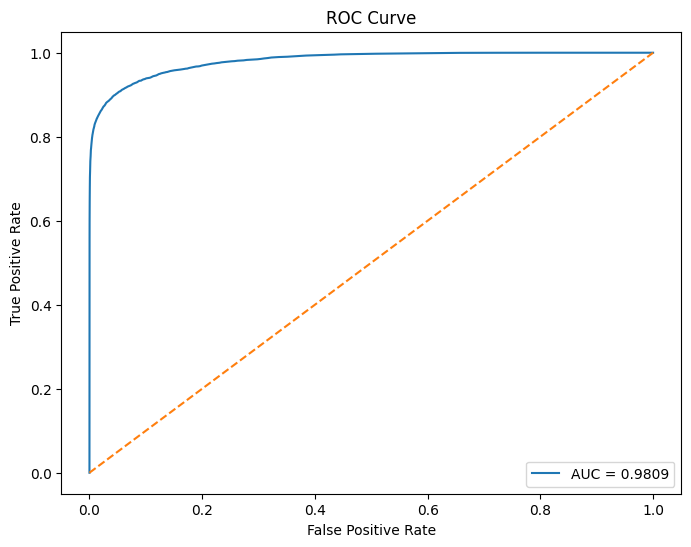

In [45]:
from sklearn.metrics import (
    roc_curve,
    auc
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve'
)

plt.legend()

plt.show()

**Precision-Recall Curve**

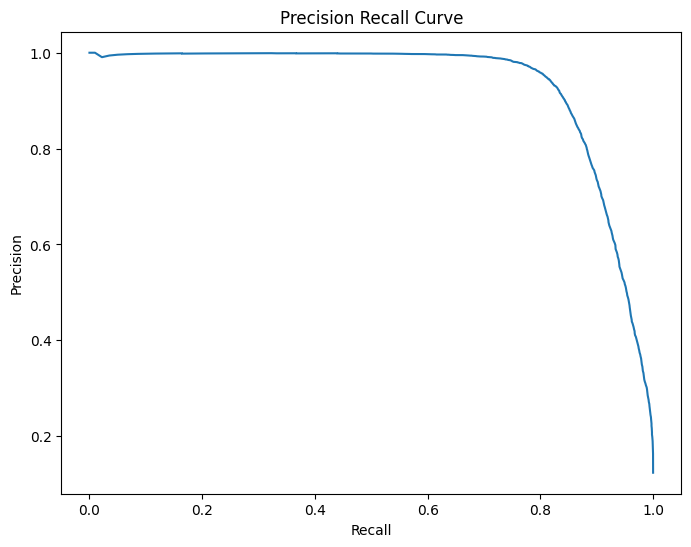

In [46]:
from sklearn.metrics import (
    precision_recall_curve
)

precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel(
    'Recall'
)

plt.ylabel(
    'Precision'
)

plt.title(
    'Precision Recall Curve'
)

plt.show()

**Feature Importance**

In [47]:
importance = pd.DataFrame({

    'Feature':
    preprocessor.get_feature_names_out(),

    'Importance':
    final_model.feature_importances_

})

In [48]:
importance = (
    importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [49]:
importance.head(20)

,Feature,Importance
10,num__Enrollment Year,0.104673
13,num__Membership_Age_Months,0.086010
9,num__CLV,0.083911
22,num__Loyalty_Efficiency,0.082971
11,num__Enrollment Month,0.077299
7,num__Salary,0.074278
12,num__Tenure,0.061526
1,num__Month,0.051556
2,num__Total Flights,0.040968
19,num__Engagement_Score,0.036401


**Plot Top 20 Features**

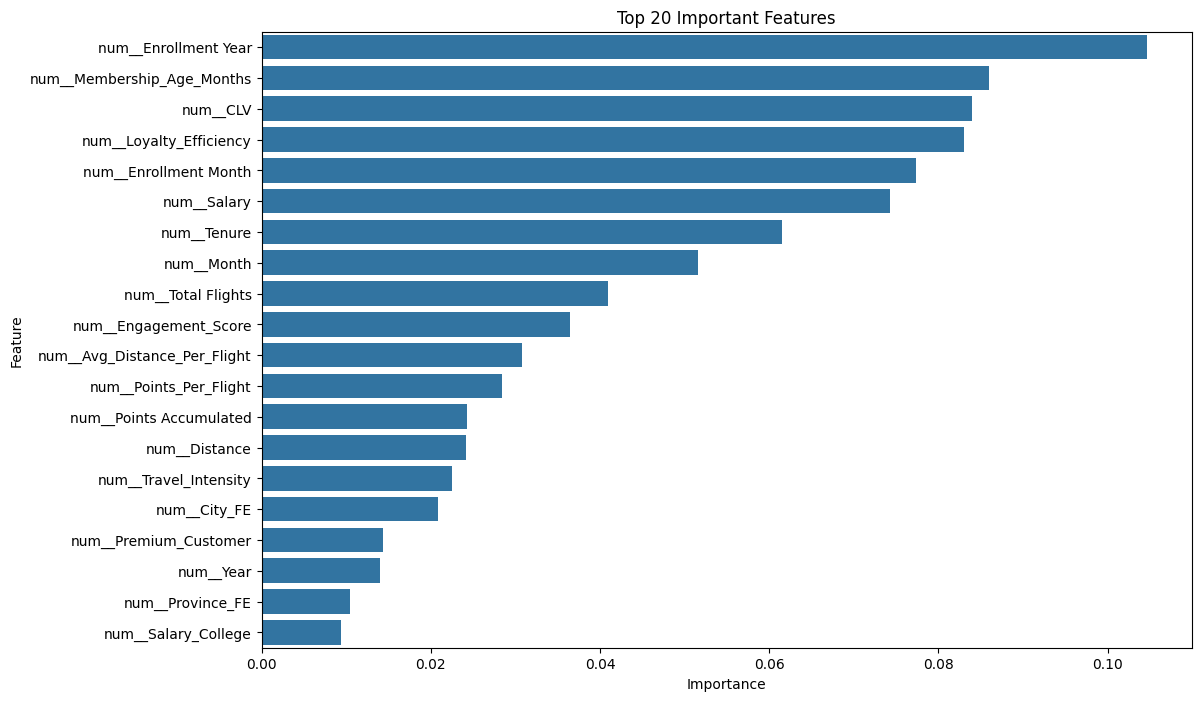

In [50]:
top20 = importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 20 Important Features'
)

plt.show()

In [51]:
importance.to_csv(
    '/content/drive/MyDrive/CAC_IITG/Airline/feature_importance.csv',
    index=False
)